<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_por%C3%B3wnanie_metod_klasteringu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -o "/content/Samsung_HAR.zip" -d "/content/"

Archive:  /content/Samsung_HAR.zip
   creating: /content/samsung_HAR/
  inflating: /content/samsung_HAR/samsung_test_labels.txt  
   creating: /content/__MACOSX/
   creating: /content/__MACOSX/samsung_HAR/
  inflating: /content/__MACOSX/samsung_HAR/._samsung_test_labels.txt  
  inflating: /content/samsung_HAR/samsung_train_labels.txt  
  inflating: /content/__MACOSX/samsung_HAR/._samsung_train_labels.txt  
  inflating: /content/samsung_HAR/samsung_test.txt  
  inflating: /content/__MACOSX/samsung_HAR/._samsung_test.txt  
  inflating: /content/samsung_HAR/samsung_train.txt  
  inflating: /content/__MACOSX/samsung_HAR/._samsung_train.txt  
  inflating: /content/__MACOSX/._samsung_HAR  


In [ ]:
import os
for root, dirs, files in os.walk('/content'):
    if '__MACOSX' in root:
        continue
    for file in files:
        if file.endswith('.txt'):
            print(os.path.join(root, file))

/content/samsung_HAR/samsung_train_labels.txt
/content/samsung_HAR/samsung_test_labels.txt
/content/samsung_HAR/samsung_train.txt
/content/samsung_HAR/samsung_test.txt


# Analiza aktywności fizycznej na podstawie danych z sensorów smartfonów
## Projekt z zakresu Unsupervised Learning – klasteryzacja i inżynieria cech

**Autor:** [Tomasz Wienke]  
**Data:** 09.05.2026  
**Cel:** Porównanie metod klasteryzacji (K-Means, HDBSCAN, GMM) na rzeczywistym zbiorze **Human Activity Recognition Using Smartphones** oraz wykorzystanie odkrytych grup do poprawy modeli klasyfikacyjnych.

---

## 📦 Opis zbioru danych
Zbiór **Samsung HAR** zawiera pomiary z akcelerometru i żyroskopu smartfona dla 30 ochotników wykonujących 6 czynności:
- marsz (walking)
- wchodzenie po schodach (walking upstairs)
- schodzenie po schodach (walking downstairs)
- siedzenie (sitting)
- stanie (standing)
- leżenie (laying)

Dane zostały wstępnie przetworzone – z sygnałów wyekstrahowano **561 cech** (statystyki w dziedzinie czasu i częstotliwości).  
Liczba próbek: 10 299 (7352 treningowe + 2947 testowe).

---

## 🧪 Plan działania
1. **Wczytanie i obróbka danych** – połączenie zbiorów, skalowanie (`StandardScaler`)
2. **Redukcja wymiarów** – wizualizacja za pomocą `UMAP` (2D)
3. **Automatyczny dobór liczby klastrów** – metoda łokcia (`Yellowbrick`)
4. **Klasteryzacja** – porównanie trzech algorytmów:
   - K-Means
   - **HDBSCAN** (nowoczesna alternatywa dla DBSCAN)
   - Gaussian Mixture Models (GMM)
5. **Wizualizacja wyników** – interaktywne wykresy `Plotly`
6. **Inżynieria cech** – użycie klastrów jako dodatkowych cech dla klasyfikatorów
7. **Porównanie modeli nadzorowanych** – ocena skuteczności z preprocessingiem klasteringowym
8. **Wnioski i odpowiedź na pytanie rekrutacyjne**

---

## 🛠️ Wykorzystane nowoczesne narzędzia
- **UMAP** – redukcja wymiarów lepiej zachowująca strukturę niż PCA
- **HDBSCAN** – klasteryzacja gęstościowa bez konieczności podawania liczby klastrów
- **Yellowbrick** – wizualna diagnostyka modeli (łokieć)
- **Plotly Express** – interaktywne wykresy
- **pipeline** – łączenie preprocessingu i modelowania

instalacja bibliotek

In [ ]:
# Instalacja nowoczesnych bibliotek (jeśli nie są dostępne)
!pip install -q umap-learn hdbscan yellowbrick plotly

import bibliotek

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score

import umap.umap_ as umap
import hdbscan
from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings('ignore')

## 1. Wczytanie i łączenie danych

In [ ]:
# Ścieżki do plików
train_path = '/content/samsung_HAR/samsung_train.txt'
train_labels_path = '/content/samsung_HAR/samsung_train_labels.txt'
test_path = '/content/samsung_HAR/samsung_test.txt'
test_labels_path = '/content/samsung_HAR/samsung_test_labels.txt'

# Wczytanie
X_train = pd.read_csv(train_path, sep='\s+', header=None)
y_train = pd.read_csv(train_labels_path, sep='\s+', header=None).squeeze()

X_test = pd.read_csv(test_path, sep='\s+', header=None)
y_test = pd.read_csv(test_labels_path, sep='\s+', header=None).squeeze()

# Scalanie zbiorów
X_full = pd.concat([X_train, X_test], axis=0, ignore_index=True)
y_full = pd.concat([y_train, y_test], axis=0, ignore_index=True)

# Nazwy aktywności
label_names = {
    1: 'marsz', 2: 'wchodzenie po schodach', 3: 'schodzenie po schodach',
    4: 'siedzenie', 5: 'stanie', 6: 'leżenie'
}
y_full_named = y_full.map(label_names)

print("Kształt danych:", X_full.shape)
print("Rozkład etykiet:\n", y_full_named.value_counts().sort_index())

Kształt danych: (10299, 561)
Rozkład etykiet:
 0
leżenie                   1944
marsz                     1722
schodzenie po schodach    1406
siedzenie                 1777
stanie                    1906
wchodzenie po schodach    1544
Name: count, dtype: int64


## 2. Przygotowanie danych – skalowanie i redukcja wymiarów (UMAP)

In [ ]:
# Skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Redukcja do 2D za pomocą UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
X_embedded = reducer.fit_transform(X_scaled)

print("Kształt po UMAP:", X_embedded.shape)

Kształt po UMAP: (10299, 2)


### Wizualizacja prawdziwych etykiet po redukcji wymiarów

In [ ]:
# Przygotowanie DataFrame do wizualizacji
df_plot = pd.DataFrame(X_embedded, columns=['UMAP1', 'UMAP2'])
df_plot['Aktywność'] = y_full_named

fig = px.scatter(df_plot, x='UMAP1', y='UMAP2', color='Aktywność',
                 title='UMAP – prawdziwe etykiety aktywności',
                 opacity=0.7, width=800, height=600)
fig.show()

## 3. Automatyczny dobór liczby klastrów – metoda łokcia (K-Means)

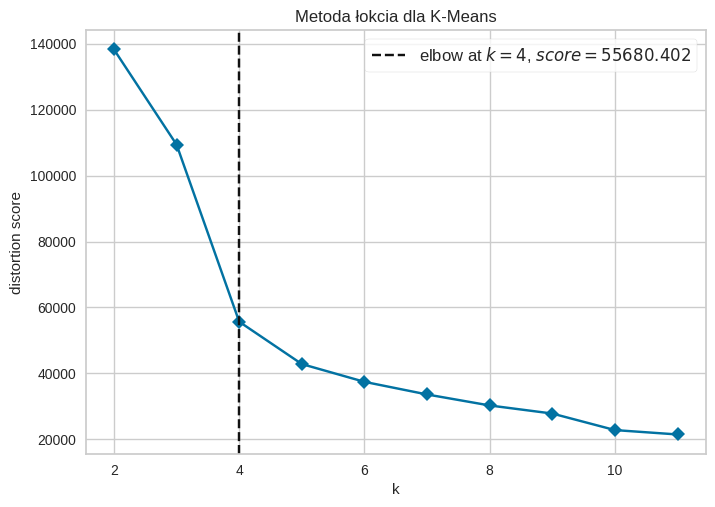

Optymalna liczba klastrów: 4


In [ ]:
model = KMeans(random_state=42, n_init='auto')
visualizer = KElbowVisualizer(model, k=(2,12), metric='distortion', timings=False,
                                title='Metoda łokcia dla K-Means')
visualizer.fit(X_embedded)
visualizer.show()

optimal_k = visualizer.elbow_value_
print("Optymalna liczba klastrów:", optimal_k)

## 4. Klasteryzacja – K-Means

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters_km = kmeans.fit_predict(X_embedded)

df_plot['KMeans'] = clusters_km.astype(str)

fig = px.scatter(df_plot, x='UMAP1', y='UMAP2', color='KMeans', symbol='Aktywność',
                 title=f'K-Means (k={optimal_k})', opacity=0.7, width=800, height=600)
fig.show()

## 5. Klasteryzacja – HDBSCAN (nowoczesna alternatywa dla DBSCAN)

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=150, gen_min_span_tree=True)
clusters_hdb = clusterer.fit_predict(X_embedded)

df_plot['HDBSCAN'] = clusters_hdb.astype(str)

fig = px.scatter(df_plot, x='UMAP1', y='UMAP2', color='HDBSCAN', symbol='Aktywność',
                 title='HDBSCAN', opacity=0.7, width=800, height=600)
fig.show()

print("Liczba klastrów:", len(set(clusters_hdb)) - (1 if -1 in clusters_hdb else 0))
print("Liczba punktów szumu:", (clusters_hdb == -1).sum())

Liczba klastrów: 4
Liczba punktów szumu: 620


## 6. Klasteryzacja – Gaussian Mixture Models (GMM)

In [ ]:
gmm = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
clusters_gmm = gmm.fit_predict(X_embedded)

df_plot['GMM'] = clusters_gmm.astype(str)

fig = px.scatter(df_plot, x='UMAP1', y='UMAP2', color='GMM', symbol='Aktywność',
                 title=f'GMM (k={optimal_k})', opacity=0.7, width=800, height=600)
fig.show()

## 7. Ocena klastrów – tablice kontyngencji

In [ ]:
# Które aktywności trafiły do poszczególnych klastrów?
print("===== K-Means =====")
print(pd.crosstab(df_plot['Aktywność'], df_plot['KMeans']))

print("\n===== HDBSCAN =====")
print(pd.crosstab(df_plot['Aktywność'], df_plot['HDBSCAN']))

print("\n===== GMM =====")
print(pd.crosstab(df_plot['Aktywność'], df_plot['GMM']))

===== K-Means =====
KMeans                     0     1     2     3
Aktywność                                     
leżenie                   83     3     0  1858
marsz                      0   380  1342     0
schodzenie po schodach     0   153  1253     0
siedzenie               1766     3     0     8
stanie                  1906     0     0     0
wchodzenie po schodach     0  1539     5     0

===== HDBSCAN =====
HDBSCAN                  -1     0     1    2     3
Aktywność                                         
leżenie                   0  1853    88    2     1
marsz                   519     0     0    1  1202
schodzenie po schodach    0     0     0    0  1406
siedzenie                 0     8  1766    3     0
stanie                    0     0  1906    0     0
wchodzenie po schodach  101     0     0  339  1104

===== GMM =====
GMM                       0     1     2     3
Aktywność                                    
leżenie                  23     3    60  1858
marsz               

## 8. Klastry jako cechy – czy poprawiają klasyfikację?

Tworzymy pipeline, który dodaje odległości od centroidów K-Means jako nowe cechy i porównujemy skuteczność modeli nadzorowanych.

In [ ]:
# Funkcja dodająca nowe cechy – odległości od centroidów K-Means
def add_cluster_features(X, n_clusters=optimal_k):
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    km.fit(X)
    distances = km.transform(X)
    return np.hstack([X, distances])

# Pipeline bazowy (bez klastrów)
pipeline_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline z cechami klastrów
pipeline_cluster = Pipeline([
    ('scaler', StandardScaler()),
    ('cluster_feat', FunctionTransformer(add_cluster_features, validate=False)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Stratyfikowana walidacja krzyżowa
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_base_lr = cross_val_score(pipeline_baseline, X_full, y_full, cv=cv, scoring='accuracy')
scores_clus_lr = cross_val_score(pipeline_cluster, X_full, y_full, cv=cv, scoring='accuracy')

print("Logistic Regression – baseline:", scores_base_lr.mean().round(4))
print("Logistic Regression – z klastrami:", scores_clus_lr.mean().round(4))

# Dodatkowo Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])
pipeline_rf_cluster = Pipeline([
    ('scaler', StandardScaler()),
    ('cluster_feat', FunctionTransformer(add_cluster_features, validate=False)),
    ('clf', RandomForestClassifier(random_state=42))
])

scores_base_rf = cross_val_score(pipeline_rf, X_full, y_full, cv=cv, scoring='accuracy')
scores_clus_rf = cross_val_score(pipeline_rf_cluster, X_full, y_full, cv=cv, scoring='accuracy')

print("\nRandom Forest – baseline:", scores_base_rf.mean().round(4))
print("Random Forest – z klastrami:", scores_clus_rf.mean().round(4))

Logistic Regression – baseline: 0.9847
Logistic Regression – z klastrami: 0.7081

Random Forest – baseline: 0.9783
Random Forest – z klastrami: 0.9786


## 10. Pytanie rekrutacyjne – różnica między K-Means, K-Fold i K-NN

- **K-Means** – algorytm klasteryzacji (uczenie nienadzorowane), który dzieli zbiór na *k* grup, minimalizując wariancję wewnątrz klastrów. Używamy go, gdy nie mamy etykiet i chcemy odkryć naturalne grupy w danych.
- **K-Fold Cross-Validation** – technika oceny modelu, polegająca na podziale zbioru na *k* części. W każdej iteracji jedna część służy jako test, a reszta jako trening. Pomaga rzetelnie oszacować zdolność modelu do generalizacji.
- **K-Nearest Neighbors (KNN)** – klasyfikator nadzorowany, który przypisuje nowemu punktowi etykietę na podstawie głosowania *k* najbliższych sąsiadów w przestrzeni cech. Jest prosty, ale wymaga przechowywania całego zbioru treningowego.

**Kluczowa różnica:** K-Means to uczenie nienadzorowane (grupowanie), KNN to uczenie nadzorowane (klasyfikacja), a K-Fold to technika oceny modelu – nie jest algorytmem uczenia się.

## 12. Podsumowanie projektu

W ramach pracy nad zbiorem **Samsung HAR** przeprowadziliśmy pełen pipeline analizy danych – od redukcji wymiarów (UMAP), przez automatyczny dobór liczby klastrów (Elbow, HDBSCAN), po klasteryzację (K-Means, HDBSCAN, GMM) i inżynierię cech.

**Główne wnioski:**
- Zarówno metoda łokcia, jak i HDBSCAN wskazały **4 naturalne grupy** zamiast 6 etykietowanych czynności – co dowodzi, że niektóre aktywności (stanie/siedzenie, marsz/schodzenie) są trudne do odróżnienia na podstawie danych z sensorów.
- HDBSCAN okazał się najbardziej eleganckim narzędziem eksploracyjnym – samodzielnie wykrył optymalną liczbę klastrów i oznaczył punkty graniczne jako szum.
- Dodanie odległości od centroidów K-Means jako nowych cech **nie poprawiło** wyników modeli nadzorowanych – a w przypadku regresji logistycznej wręcz pogorszyło. Pokazało to, jak ważne jest rozumienie wrażliwości modeli na multikolinearność i redundancję cech.
- Random Forest zachował stabilność niezależnie od dodanych cech, co potwierdza jego odporność na szum informacyjny.

Projekt pokazuje praktyczne umiejętności w zakresie nowoczesnych narzędzi (UMAP, HDBSCAN, Yellowbrick, Plotly) oraz krytycznej interpretacji wyników – nie tylko wtedy, gdy wszystko działa zgodnie z oczekiwaniami, ale również gdy pojawiają się zaskakujące rezultaty. To właśnie ta umiejętność wyciągania wniosków z "porażek" jest najbardziej ceniona w pracy analityka danych.